In [3]:
import torch 
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

#### Training

In [4]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

In [5]:
flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()
losses = []

for j in range(10000):
    # x_1 = Tensor(make_moons(256, noise=0.15)[0])
    x_1 = Tensor(make_swiss_roll(256, noise=0.05)[0][:, [0, 2]])
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss = loss_fn(flow(t=t, x_t=x_t), dx_t)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if j % 1000 == 0:
        print(f"Step {j}, Loss: {loss.item():.4f}")


Step 0, Loss: 48.7219
Step 1000, Loss: 9.7386
Step 2000, Loss: 11.6008
Step 3000, Loss: 8.6030
Step 4000, Loss: 8.9274
Step 5000, Loss: 10.9447
Step 6000, Loss: 7.6675
Step 7000, Loss: 8.4965
Step 8000, Loss: 9.1474
Step 9000, Loss: 11.6843


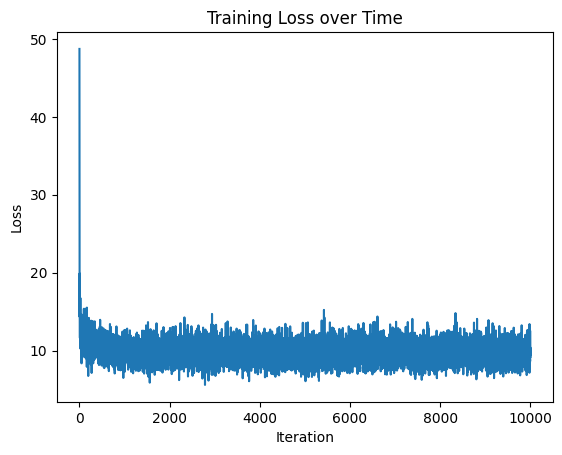

In [6]:
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.show()

#### Sampling

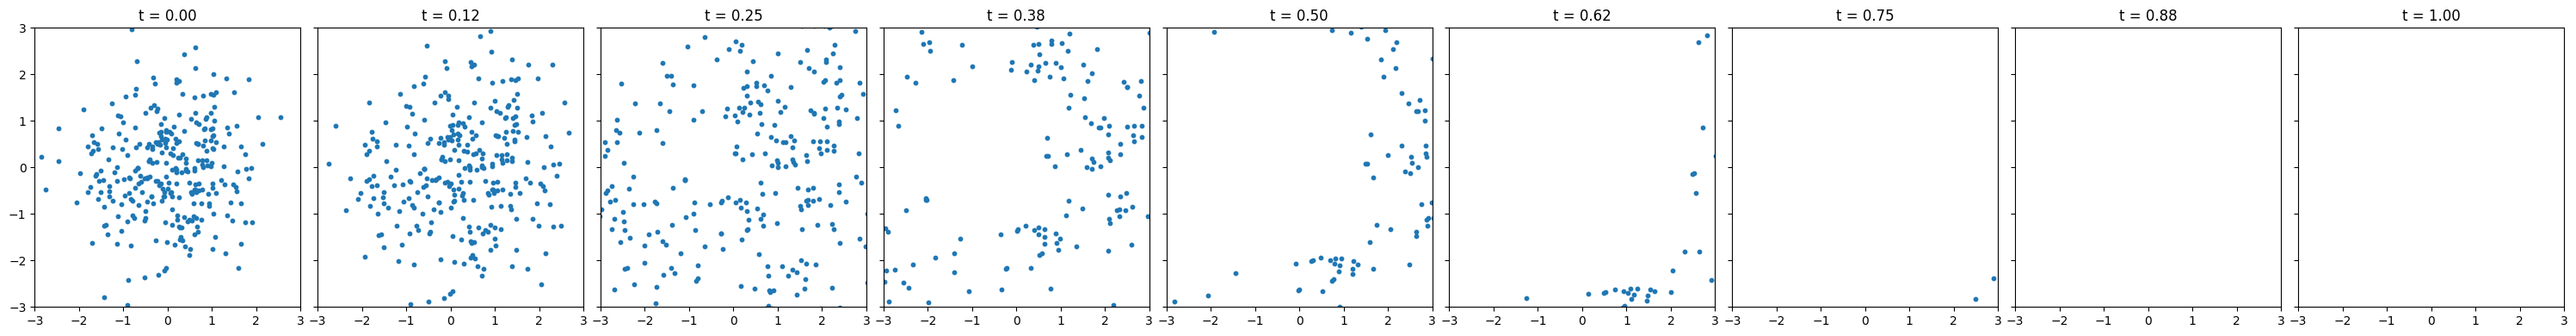

In [7]:
x = torch.randn(300, 2)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

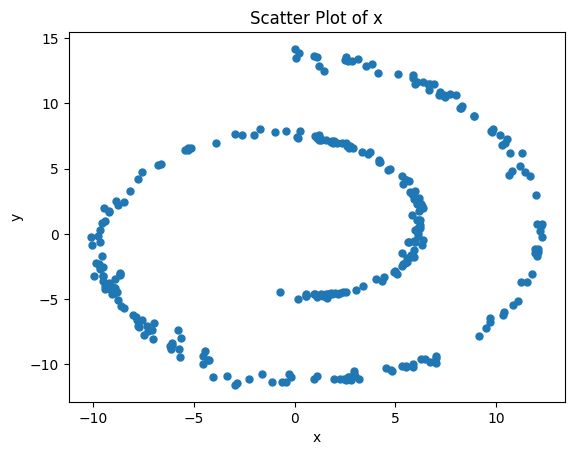

: 

In [ ]:
plt.plot(x[:, 0].detach(), x[:, 1].detach(), 'o', markersize=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of x')
plt.show()